In [1]:
library(tidyverse)
library(glue)

Warning message:
“package ‘tibble’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [32]:
# Run mmseqs for every reference against the complete references
system("mkdir -p mmseqs-results")
# Uncomment to run mmseqs2 searches
consensus_files <- list.files("consensus", pattern = "\\.fasta$", full.names = TRUE)

walk(consensus_files, function(fasta) {
  basename <- str_remove(basename(fasta), "\\.fasta$")
  potential_references <- "ncbi-virus-fasta/sequences_20251024_LASV.fasta"
  message(glue("Running mmseqs2 for {basename}\n"))
  system(glue("conda run -n mmseqs2-env mmseqs easy-search --search-type 3 {fasta} {potential_references} mmseqs-results/{basename}_mmseqs.out.m8 tmp"))
})

Running mmseqs2 for LASV_L

Running mmseqs2 for LASV_S



In [33]:
colnames_mmseqs <- str_split("query,target,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue,bits", ",")[[1]]

mmseqs <- list.files("mmseqs-results/") %>%
    map_dfr(~ {
        df <- read.table(paste0("mmseqs-results/", .), sep="\t", col.names = colnames_mmseqs)
        df$segment <- .
        df
    }) %>%
    mutate(segment = gsub(".*_(S|L|M)_.*", "\\1", segment))

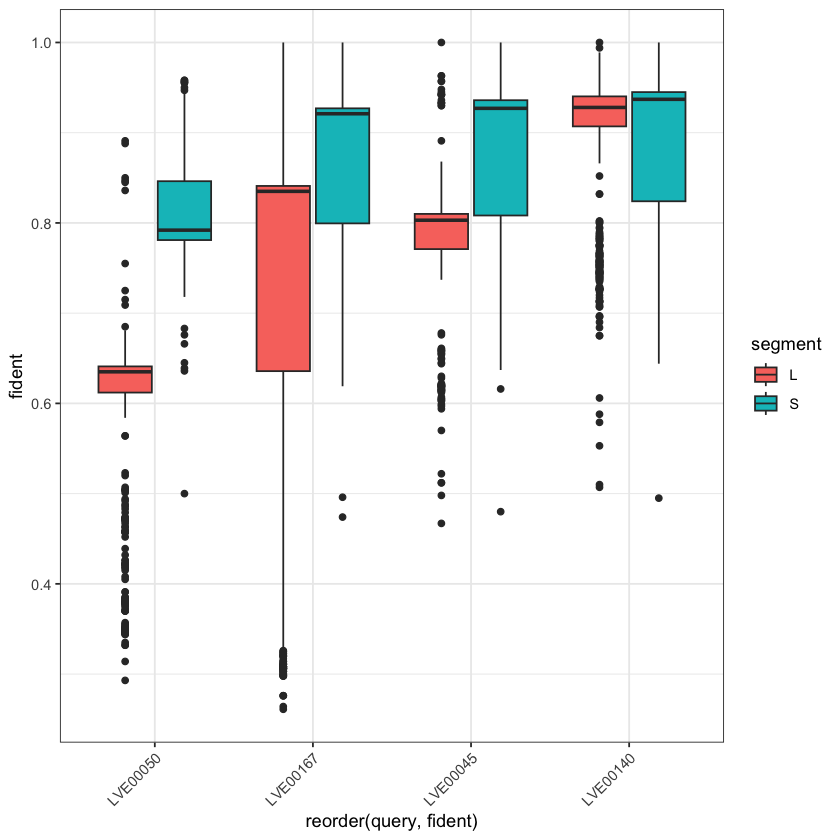

In [34]:
# Checking the observed diversity of references. (arrange with increasing mean fident)
ggplot(mmseqs, aes(y = fident, x = reorder(query, fident), fill=segment)) +
  geom_boxplot() +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [50]:
set.seed(42)
# Selecting a reference for each query in a window of [[80,82],[82,84],...,[98,100]]
selected_references <- mmseqs %>%
  filter(fident >=0.64) %>%
  mutate(fident_window = cut(fident, breaks = seq(0.64, 1, by = 0.02), include.lowest = TRUE)) %>%
  group_by(query, fident_window) %>%
  arrange(desc(alnlen)) %>%
  slice(1)

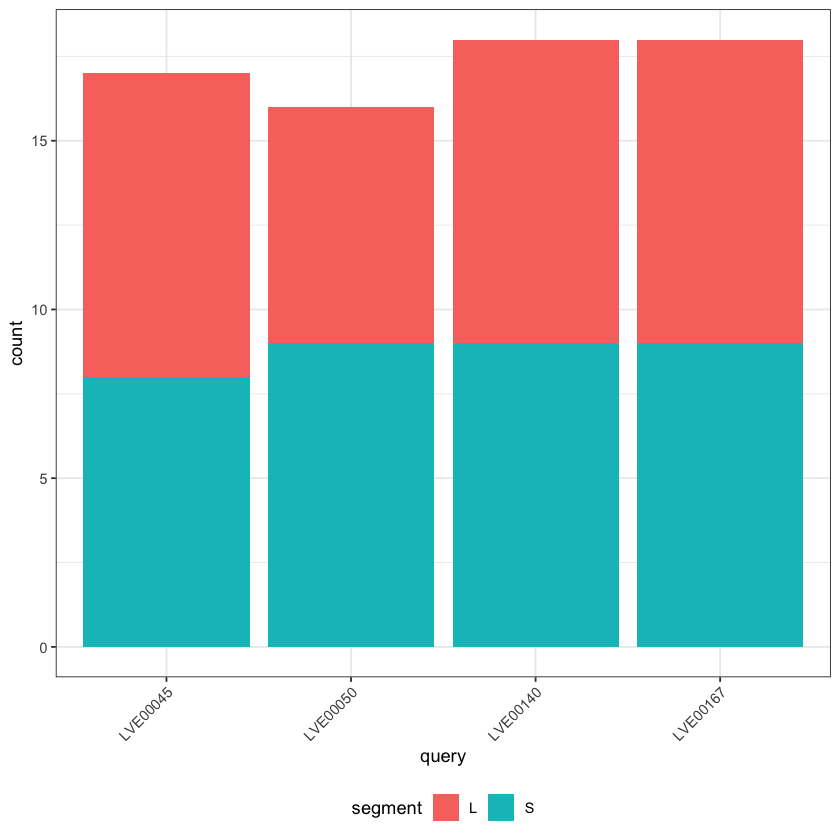

In [51]:
# Checking how many we have for every query
ggplot(selected_references, aes(x = query, fill = segment)) +
  geom_bar() +
  theme_bw() +
  theme(legend.position = "bottom") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

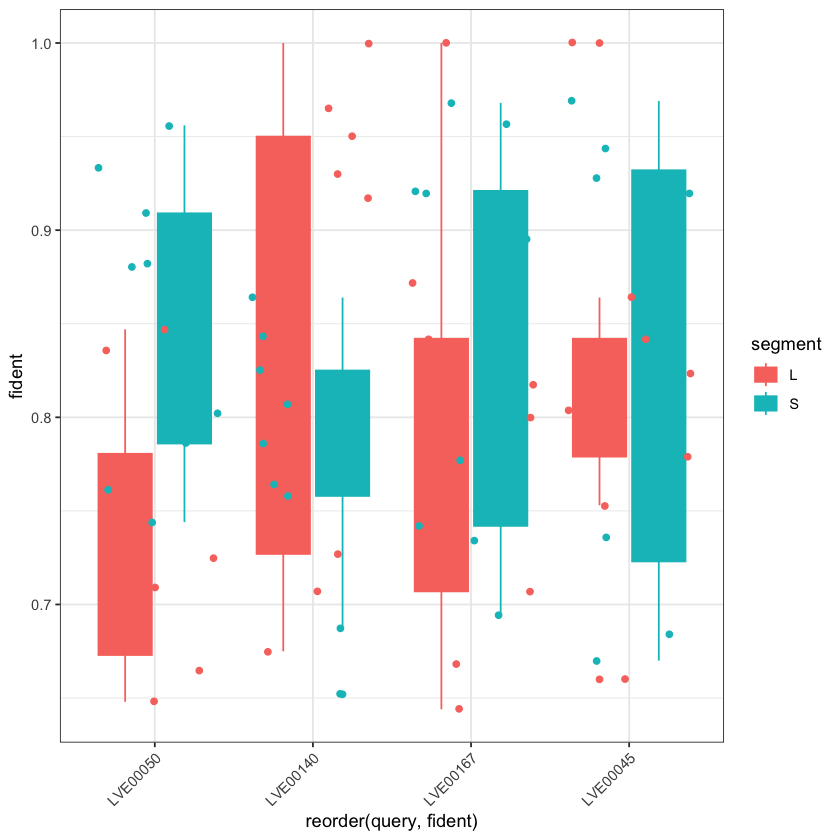

In [52]:
# Checking the observed diversity of references. (arrange with increasing mean fident)
ggplot(selected_references, aes(y = fident, x = reorder(query, fident), fill = segment, color=segment)) +
  geom_boxplot() +
  geom_jitter() +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

Not going to worry too much about it, I'm just going to start by selecting one sample (LVE00050) and one reference per window of identity.


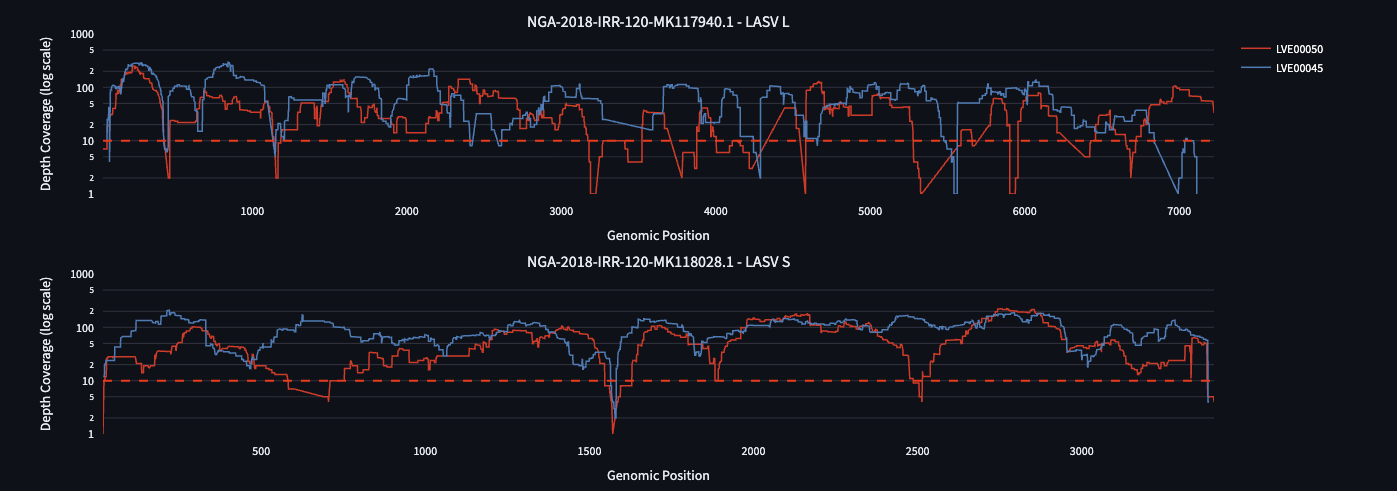


In [ ]:
fident_window_to_digits <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2])
  hi <- as.numeric(rng[, 3])
  sprintf("%02d%02d", round(lo * 100), round(hi * 100))
}

system("mkdir -p selected-references")


### FOR NOW ONLY FOCUSING ON S Segment
collapse <- selected_references%>%
    group_by(query, fident_window)%>%
    summarise(targets_regex = paste(target,collapse = " " ))%>%
    ungroup()

`summarise()` has grouped output by 'query'. You can override using the
`.groups` argument.


In [58]:
system("mkdir -p selected-references")

apply(collapse, 1, function(x) {
    sample <- x[1]
    fident_window <- x[2]
    targets_regex <- x[3]
    fident_digits <- fident_window_to_digits(fident_window)
    outname <- gsub(" ", "-", targets_regex)
    regex <- gsub(" ",")|(", targets_regex)
    out_file <- glue("{out_dir}/{fident_digits}_{outname}.fasta")
    command <- glue("cat ncbi-virus-fasta/sequences_*_LASV.fasta | seqkit grep -r -p '({regex})' > {out_file}")
    system(command)
})

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[39] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [56]:
unique(collapse$query)

[1] "LVE00045" "LVE00050" "LVE00140" "LVE00167"

In [62]:
head(collapse)

query,fident_window,targets_regex
<chr>,<fct>,<chr>
LVE00045,"[0.64,0.66]",MT199231.1
LVE00045,"(0.66,0.68]",PP431163.1
LVE00045,"(0.68,0.7]",OR041677.1
LVE00045,"(0.72,0.74]",OR041684.1
LVE00045,"(0.74,0.76]",MK117836.1
LVE00045,"(0.76,0.78]",ON569374.1


In [63]:
RVDB <- data.frame(
        sample = c('LVE00045','LVE00050','LVE00140','LVE00167'),
        sequence = rep("/lustre1/project/stg_00132/databases/RVDB/U-RVDBv29.0.fasta", 4))%>%
    mutate(
        id= glue("{sample}-RVDB")
    )

    collapse%>%
        mutate(
            id= glue("{query}-{fident_window_to_digits(fident_window)}"),
            sample = query,
            sequence = glue("data-preparation/{out_dir}/{fident_window_to_digits(fident_window)}_{gsub(' ', '-', targets_regex)}.fasta")
        )%>%
        select(id, sample, sequence)%>%
        bind_rows(., RVDB)%>%
        arrange(factor(sample, levels=c('LVE00050','LVE00045','LVE00140','LVE00167')))%>%
        write_csv("../reference_pools.csv")